# 02 — Prévision de la Consommation
## Projet PFE : Système Intelligent de Gestion de l'Eau — Grand Agadir

**4 modèles comparés :**
| Modèle | Type | Librairie |
|---|---|---|
| SARIMA | Statistique saisonnier | statsmodels |
| Prophet | Machine Learning temporel | prophet |
| XGBoost | Gradient Boosting | xgboost |
| LSTM | Deep Learning séquentiel | tensorflow/keras |

**Métriques de comparaison :** MAE, RMSE, MAPE  
**Split :** Train 01/02→14/08/2025 | Test 15/08→29/09/2025  
**Corrections appliquées :** `rainfall` supprimé (r=0.90 avec month), 30 sept exclu

---
## 0. Imports & Configuration

In [1]:
import sys
!{sys.executable} -m pip install prophet xgboost tensorflow scikit-learn statsmodels --quiet
print('✅ Dépendances installées')

✅ Dépendances installées



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

# ── Modèles ──────────────────────────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

# ── Chemins ───────────────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
MODEL_DIR = Path('../models')
FIG_DIR   = Path('../reports/figures')
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Seed reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Imports OK')
print(f'   TensorFlow : {tf.__version__}')
print(f'   XGBoost    : {xgb.__version__}')

✅ Imports OK
   TensorFlow : 2.21.0
   XGBoost    : 3.2.0


---
## 1. Chargement & Préparation des Données

In [3]:
# ── Chargement train / test ───────────────────────────────────────────────────
df_train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['timestamp'])
df_test  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['timestamp'])

print(f'Train : {len(df_train):,} lignes  ({df_train.timestamp.min().date()} → {df_train.timestamp.max().date()})')
print(f'Test  : {len(df_test):,} lignes  ({df_test.timestamp.min().date()} → {df_test.timestamp.max().date()})')
print(f'Colonnes ({len(df_train.columns)}) : {list(df_train.columns)}')

Train : 224,640 lignes  (2025-02-01 → 2025-08-14)
Test  : 52,992 lignes  (2025-08-15 → 2025-09-29)
Colonnes (19) : ['timestamp', 'meterid', 'zone', 'quartier', 'latitude', 'longitude', 'consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'hour', 'dayofweek', 'month', 'isweekend', 'season', 'household_size', 'event_type', 'anomalylabel', 'temp_bin']


In [4]:
# ── Stratégie : on travaille sur UN compteur représentatif ────────────────────
# Pour SARIMA et LSTM : série univariée par compteur
# Pour Prophet et XGBoost : on peut utiliser tous les compteurs
# On choisit le compteur avec la consommation médiane (le plus représentatif)

median_conso = df_train.groupby('meterid')['consumptionliters'].mean()
TARGET_METER = median_conso.sub(median_conso.median()).abs().idxmin()
print(f'🎯 Compteur cible (le plus médian) : {TARGET_METER}')
print(f'   Conso moyenne : {median_conso[TARGET_METER]:.1f} L/h')

# Extraire la série de ce compteur
train_m = df_train[df_train['meterid'] == TARGET_METER].sort_values('timestamp').copy()
test_m  = df_test[df_test['meterid']  == TARGET_METER].sort_values('timestamp').copy()

print(f'\n📊 Série du compteur {TARGET_METER} :')
print(f'   Train : {len(train_m):,} points horaires')
print(f'   Test  : {len(test_m):,} points horaires')

🎯 Compteur cible (le plus médian) : M031
   Conso moyenne : 413.7 L/h

📊 Série du compteur M031 :
   Train : 18,720 points horaires
   Test  : 4,416 points horaires


In [5]:
# ── Fonction de métriques (partagée par tous les modèles) ─────────────────────
def compute_metrics(y_true, y_pred, model_name='Modèle'):
    """Calcule MAE, RMSE, MAPE et retourne un dict."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Éviter division par zéro dans MAPE
    mask = y_true > 1
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'\n📊 {model_name}')
    print(f'   MAE  : {mae:.2f} L')
    print(f'   RMSE : {rmse:.2f} L')
    print(f'   MAPE : {mape:.2f} %')
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Stocker tous les résultats
results = []
print('✅ Fonction compute_metrics prête')

✅ Fonction compute_metrics prête


---
## 2. Modèle 1 — SARIMA

In [6]:
# ── Paramètres issus de l'EDA ─────────────────────────────────────────────────
# ADF → stationnaire (d=0)
# PACF coupe après lag 2 → p=2
# ACF décroit lentement → q=1
# Saisonnalité journalière s=24
# On entraîne sur les 30 derniers jours du train (SARIMA lent sur longues séries)

print('⏳ Entraînement SARIMA(2,0,1)(1,0,1)[24]...')
print('   (patience, ~2-3 min sur 720 points)')

# Série des 30 derniers jours du train pour ce compteur
sarima_train = train_m.set_index('timestamp')['consumptionliters'].last('30D')
sarima_test  = test_m.set_index('timestamp')['consumptionliters']

# On prédit uniquement les 7 premiers jours du test (168h) pour rester rapide
N_SARIMA = 24 * 7
sarima_test_short = sarima_test.iloc[:N_SARIMA]

model_sarima = SARIMAX(
    sarima_train,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarima = model_sarima.fit(disp=False)
print('✅ SARIMA entraîné')
print(fit_sarima.summary().tables[0])

⏳ Entraînement SARIMA(2,0,1)(1,0,1)[24]...
   (patience, ~2-3 min sur 720 points)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


✅ SARIMA entraîné
                                     SARIMAX Results                                      
Dep. Variable:                  consumptionliters   No. Observations:                 2880
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -22622.428
Date:                            Thu, 18 Jun 2026   AIC                          45256.857
Time:                                    19:56:46   BIC                          45292.596
Sample:                                07-16-2025   HQIC                         45269.745
                                     - 08-14-2025                                         
Covariance Type:                              opg                                         



📊 SARIMA(2,0,1)(1,0,1)[24]
   MAE  : 1020.92 L
   RMSE : 1236.35 L
   MAPE : 170.32 %


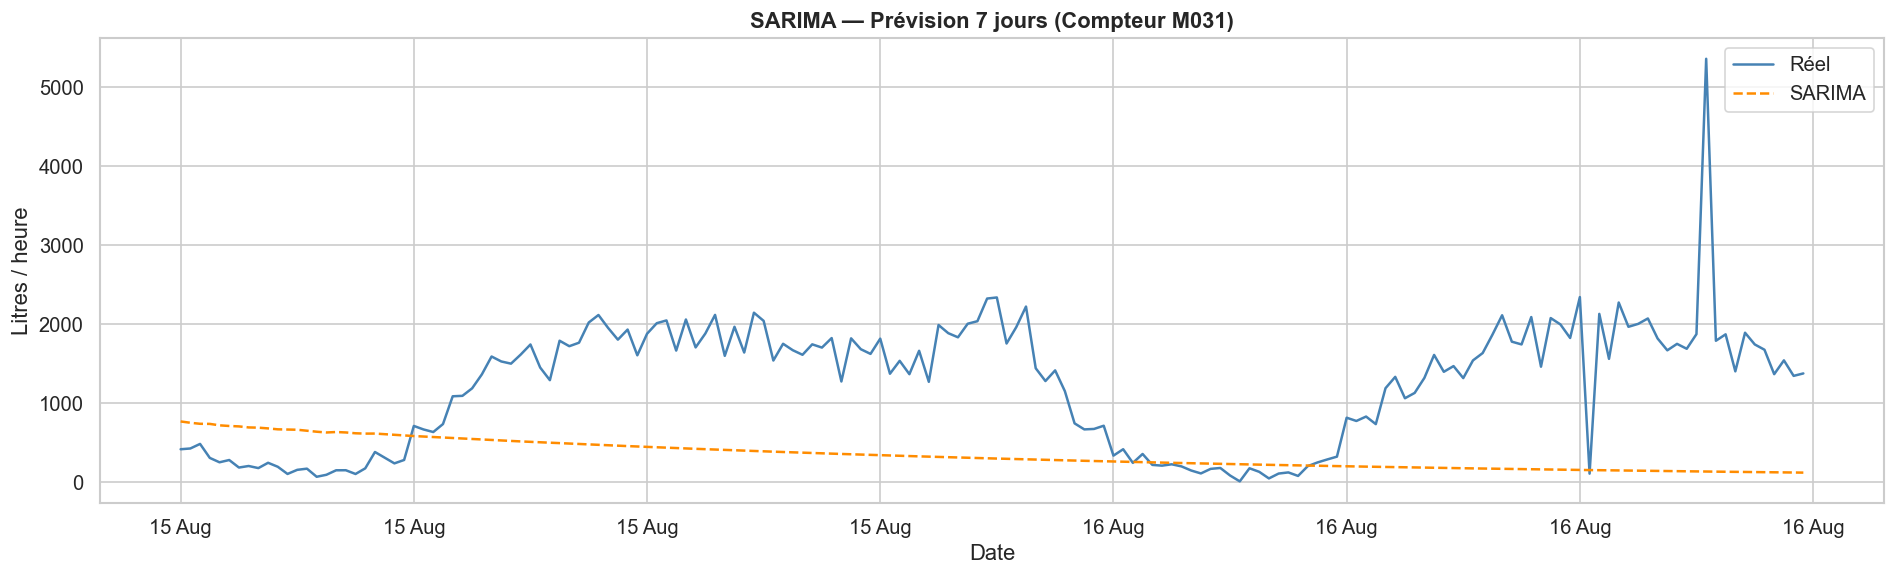

In [7]:
# ── Prédiction SARIMA ─────────────────────────────────────────────────────────
pred_sarima = fit_sarima.forecast(steps=N_SARIMA)
pred_sarima = np.clip(pred_sarima, 0, None)  # pas de valeurs négatives

metrics_sarima = compute_metrics(
    sarima_test_short.values, pred_sarima, 'SARIMA(2,0,1)(1,0,1)[24]'
)
results.append(metrics_sarima)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sarima_test_short.index, sarima_test_short.values,
        label='Réel', color='steelblue', linewidth=1.5)
ax.plot(sarima_test_short.index, pred_sarima,
        label='SARIMA', color='darkorange', linewidth=1.5, linestyle='--')
ax.set_title(f'SARIMA — Prévision 7 jours (Compteur {TARGET_METER})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig21_sarima_prediction.png', bbox_inches='tight')
plt.show()

---
## 3. Modèle 2 — Prophet

In [8]:
# ── Préparation des données Prophet (format ds / y) ───────────────────────────
prophet_train = train_m[['timestamp', 'consumptionliters', 'event_type']].copy()
prophet_train.columns = ['ds', 'y', 'event_type']

prophet_test = test_m[['timestamp', 'consumptionliters', 'event_type']].copy()
prophet_test.columns = ['ds', 'y', 'event_type']

# Encoder event_type comme regressor numérique
le_prophet = LabelEncoder()
prophet_train['event_num'] = le_prophet.fit_transform(prophet_train['event_type'])
prophet_test['event_num']  = le_prophet.transform(
    prophet_test['event_type'].map(
        lambda x: x if x in le_prophet.classes_ else le_prophet.classes_[0]
    )
)

print('✅ Données Prophet prêtes')
print(f'   Classes event_type : {list(le_prophet.classes_)}')

✅ Données Prophet prêtes
   Classes event_type : ['festival', 'holiday', 'normal', 'ramadan']


In [9]:
# ── Entraînement Prophet ──────────────────────────────────────────────────────
print('⏳ Entraînement Prophet...')

model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,   # seulement 8 mois de données
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)
model_prophet.add_regressor('event_num')
model_prophet.fit(prophet_train[['ds', 'y', 'event_num']])
print('✅ Prophet entraîné')

⏳ Entraînement Prophet...


19:56:49 - cmdstanpy - INFO - Chain [1] start processing
19:56:54 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet entraîné



📊 Prophet
   MAE  : 440.95 L
   RMSE : 659.33 L
   MAPE : 255.70 %


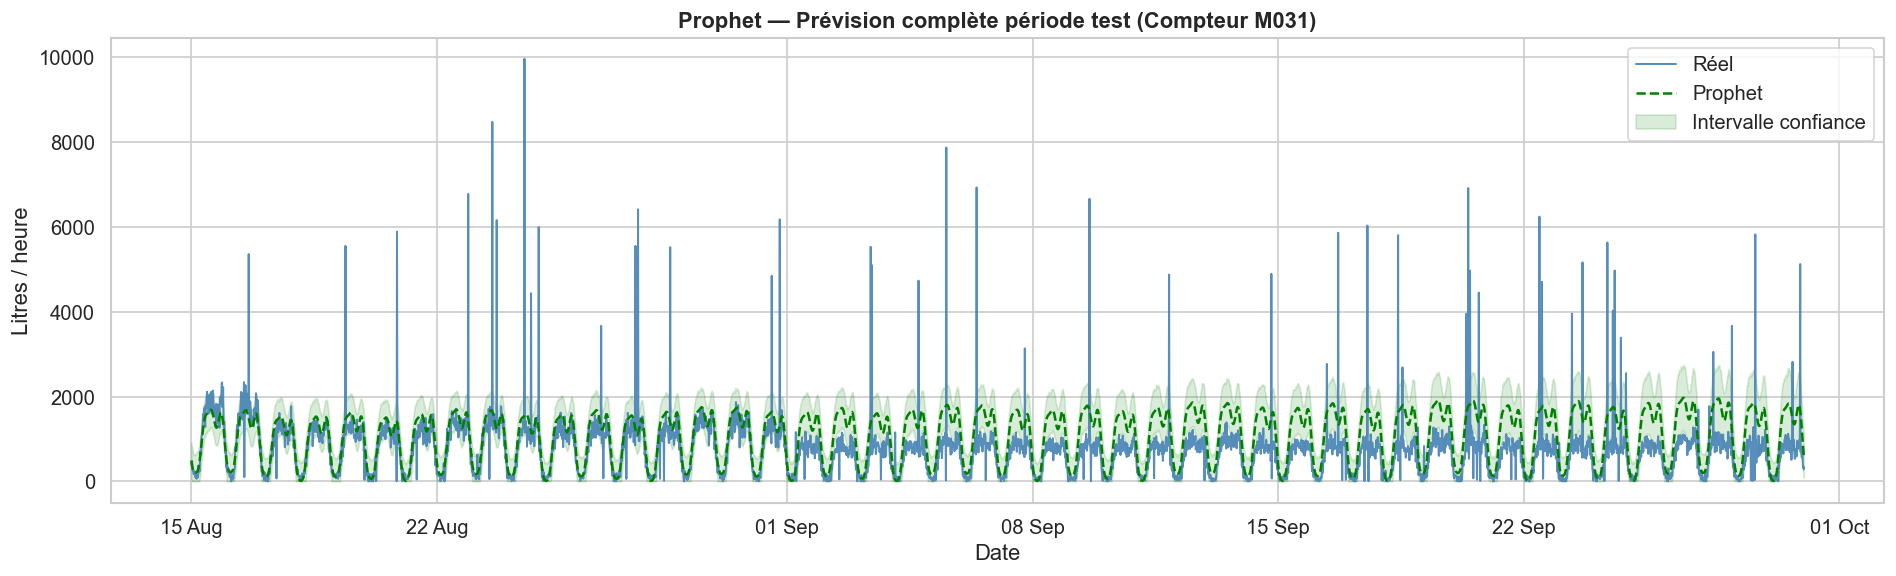

In [10]:
# ── Prédiction Prophet ────────────────────────────────────────────────────────
future_prophet = prophet_test[['ds', 'event_num']].copy()
forecast_prophet = model_prophet.predict(future_prophet)

pred_prophet = np.clip(forecast_prophet['yhat'].values, 0, None)
y_true_prophet = prophet_test['y'].values

metrics_prophet = compute_metrics(y_true_prophet, pred_prophet, 'Prophet')
results.append(metrics_prophet)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
dates = prophet_test['ds'].values
ax.plot(dates, y_true_prophet, label='Réel', color='steelblue', linewidth=1.2, alpha=0.9)
ax.plot(dates, pred_prophet,   label='Prophet', color='green', linewidth=1.5, linestyle='--')
ax.fill_between(dates,
    np.clip(forecast_prophet['yhat_lower'].values, 0, None),
    forecast_prophet['yhat_upper'].values,
    alpha=0.15, color='green', label='Intervalle confiance')
ax.set_title(f'Prophet — Prévision complète période test (Compteur {TARGET_METER})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig22_prophet_prediction.png', bbox_inches='tight')
plt.show()

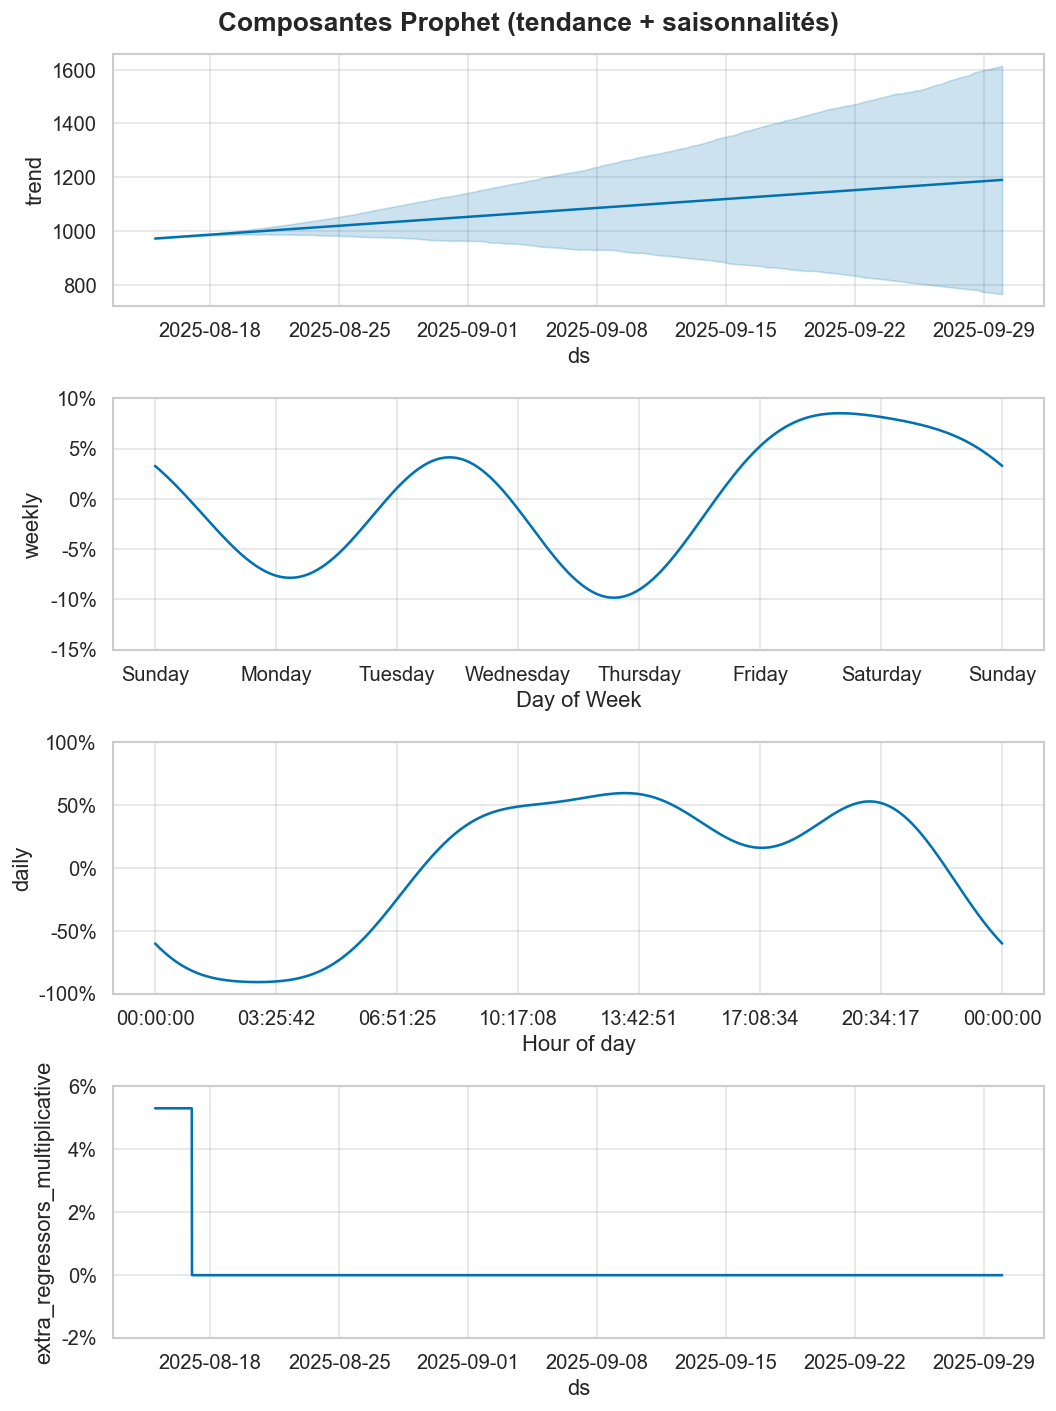

In [11]:
# ── Composantes Prophet ───────────────────────────────────────────────────────
fig_comp = model_prophet.plot_components(forecast_prophet)
fig_comp.suptitle('Composantes Prophet (tendance + saisonnalités)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig23_prophet_composantes.png', bbox_inches='tight')
plt.show()

---
## 4. Modèle 3 — XGBoost

In [12]:
# ── Feature Engineering XGBoost ───────────────────────────────────────────────
def build_features_xgb(df):
    """Construit les features pour XGBoost."""
    d = df.copy()
    d = d.sort_values('timestamp')
    
    # Features temporelles cycliques (sin/cos pour respecter la circularité)
    d['hour_sin']   = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']   = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin']    = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']    = np.cos(2 * np.pi * d['dayofweek'] / 7)
    d['month_sin']  = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']  = np.cos(2 * np.pi * d['month'] / 12)
    
    # Lags (valeurs passées de la cible)
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        d[f'lag_{lag}'] = d.groupby('meterid')['consumptionliters'].shift(lag)
    
    # Moyennes glissantes
    d['roll_mean_24'] = d.groupby('meterid')['consumptionliters'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).mean()
    )
    d['roll_mean_168'] = d.groupby('meterid')['consumptionliters'].transform(
        lambda x: x.shift(1).rolling(168, min_periods=1).mean()
    )
    d['roll_std_24'] = d.groupby('meterid')['consumptionliters'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).std()
    )
    
    # Encoder event_type
    event_map = {'normal': 0, 'holiday': 1, 'festival': 2, 'ramadan': 3}
    d['event_num'] = d['event_type'].map(event_map).fillna(0).astype(int)
    
    return d

# Features à utiliser
XGB_FEATURES = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'isweekend', 'temperaturec', 'household_size',
    'event_num', 'pressurebar', 'flowratelpm',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48',
    'roll_mean_24', 'roll_mean_168', 'roll_std_24'
]
# Filtrer les colonnes existantes
XGB_FEATURES = [f for f in XGB_FEATURES if f in df_train.columns or 
                f in ['hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
                       'event_num','lag_1','lag_2','lag_3','lag_6','lag_12','lag_24','lag_48',
                       'roll_mean_24','roll_mean_168','roll_std_24']]

print('⚙️  Construction des features...')
train_xgb = build_features_xgb(df_train)
test_xgb  = build_features_xgb(pd.concat([df_train, df_test]).sort_values(['meterid','timestamp']))
test_xgb  = test_xgb[test_xgb['timestamp'] >= df_test['timestamp'].min()]

# Supprimer les NaN créés par les lags
train_xgb = train_xgb.dropna(subset=XGB_FEATURES)
test_xgb  = test_xgb.dropna(subset=XGB_FEATURES)

# S'assurer que les features existent
available = [f for f in XGB_FEATURES if f in train_xgb.columns]
print(f'✅ {len(available)} features disponibles')
print(f'   {available}')

⚙️  Construction des features...
✅ 22 features disponibles
   ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'isweekend', 'temperaturec', 'household_size', 'event_num', 'pressurebar', 'flowratelpm', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'roll_mean_24', 'roll_mean_168', 'roll_std_24']


In [13]:
# ── Entraînement XGBoost ──────────────────────────────────────────────────────
print('⏳ Entraînement XGBoost...')

X_train_xgb = train_xgb[available].values
y_train_xgb = train_xgb['consumptionliters'].values
X_test_xgb  = test_xgb[available].values
y_test_xgb  = test_xgb['consumptionliters'].values

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0
)

# Split validation interne (derniers 20% du train)
split_val = int(len(X_train_xgb) * 0.8)
X_val = X_train_xgb[split_val:]
y_val = y_train_xgb[split_val:]
X_tr  = X_train_xgb[:split_val]
y_tr  = y_train_xgb[:split_val]

model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f'✅ XGBoost entraîné — {model_xgb.best_iteration} arbres')

⏳ Entraînement XGBoost...
✅ XGBoost entraîné — 101 arbres



📊 XGBoost
   MAE  : 48.56 L
   RMSE : 178.70 L
   MAPE : 11.29 %


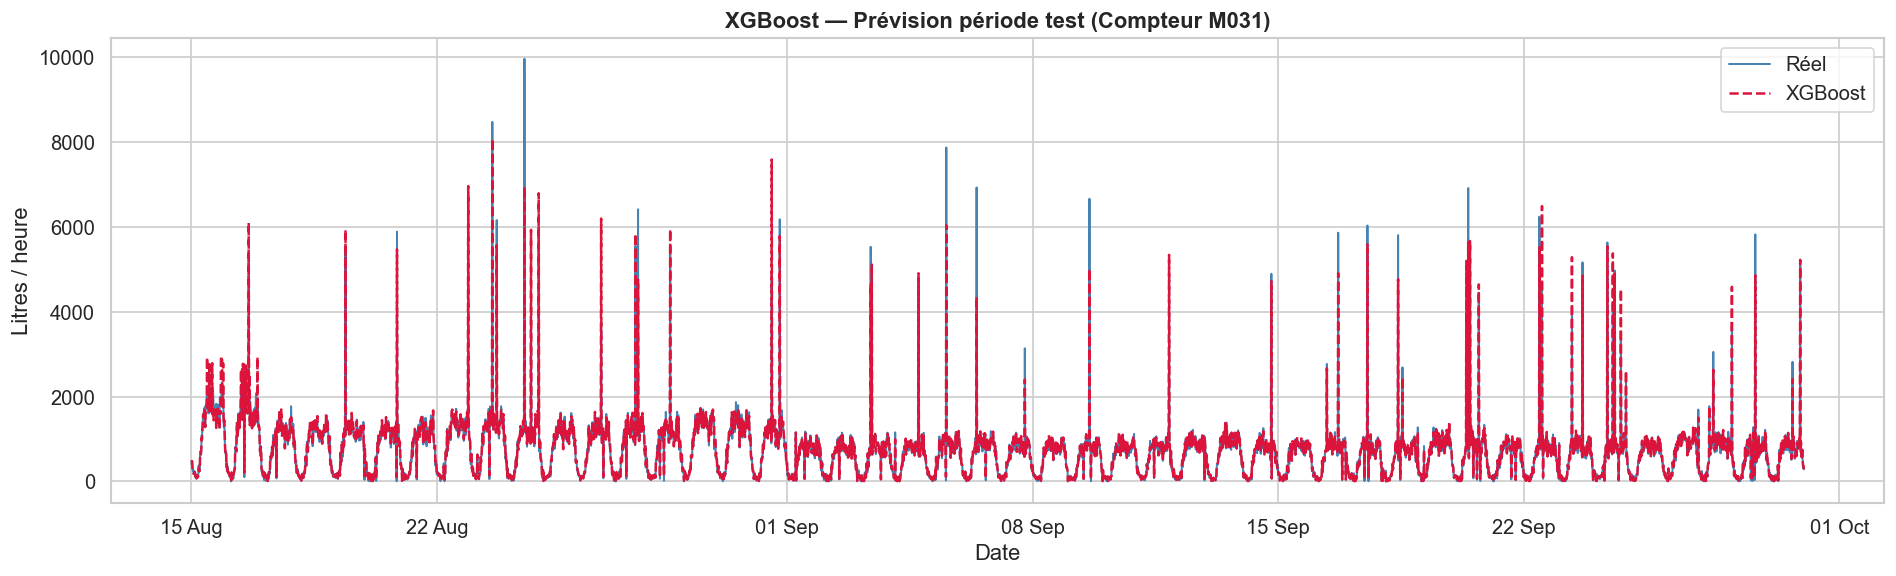

In [14]:
# ── Prédiction XGBoost ────────────────────────────────────────────────────────
pred_xgb = np.clip(model_xgb.predict(X_test_xgb), 0, None)

metrics_xgb = compute_metrics(y_test_xgb, pred_xgb, 'XGBoost')
results.append(metrics_xgb)

# ── Visualisation sur le compteur cible ───────────────────────────────────────
test_xgb_m = test_xgb[test_xgb['meterid'] == TARGET_METER].copy()
pred_xgb_m = np.clip(model_xgb.predict(test_xgb_m[available].values), 0, None)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_xgb_m['timestamp'], test_xgb_m['consumptionliters'],
        label='Réel', color='steelblue', linewidth=1.2)
ax.plot(test_xgb_m['timestamp'], pred_xgb_m,
        label='XGBoost', color='crimson', linewidth=1.5, linestyle='--')
ax.set_title(f'XGBoost — Prévision période test (Compteur {TARGET_METER})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig24_xgboost_prediction.png', bbox_inches='tight')
plt.show()

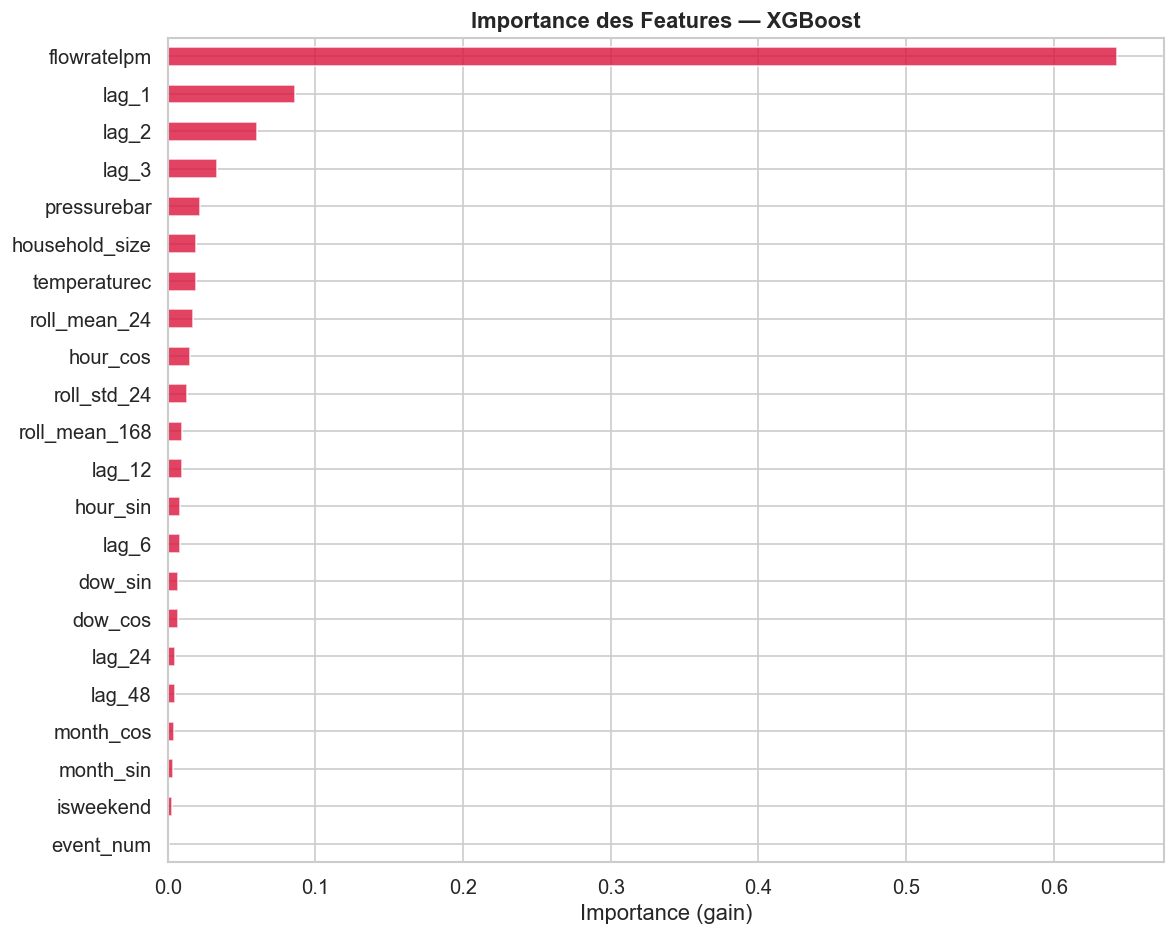

In [15]:
# ── Importance des features XGBoost ──────────────────────────────────────────
importances = pd.Series(
    model_xgb.feature_importances_, index=available
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind='barh', color='crimson', alpha=0.8, ax=ax)
ax.set_title('Importance des Features — XGBoost', fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig25_xgboost_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 5. Modèle 4 — LSTM

In [16]:
# ── Préparation des données LSTM ──────────────────────────────────────────────
# LSTM : séquences glissantes de 24h → prédire la valeur suivante
SEQ_LEN = 24  # fenêtre = 24 heures

# Série du compteur cible uniquement
series_train = train_m['consumptionliters'].values.reshape(-1, 1)
series_test  = test_m['consumptionliters'].values.reshape(-1, 1)

# Normalisation
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
series_train_sc = scaler_lstm.fit_transform(series_train)
series_test_sc  = scaler_lstm.transform(series_test)

def make_sequences(data, seq_len):
    """Crée des séquences (X, y) pour le LSTM."""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = make_sequences(series_train_sc, SEQ_LEN)

# Pour le test, on concatène la fin du train pour avoir les premiers lags
series_full_sc = np.concatenate([series_train_sc[-SEQ_LEN:], series_test_sc])
X_test_lstm, y_test_lstm = make_sequences(series_full_sc, SEQ_LEN)

# Reshape pour LSTM : (samples, timesteps, features)
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], SEQ_LEN, 1)
X_test_lstm  = X_test_lstm.reshape(X_test_lstm.shape[0], SEQ_LEN, 1)

print(f'✅ Données LSTM prêtes')
print(f'   X_train : {X_train_lstm.shape}  y_train : {y_train_lstm.shape}')
print(f'   X_test  : {X_test_lstm.shape}   y_test  : {y_test_lstm.shape}')

✅ Données LSTM prêtes
   X_train : (18696, 24, 1)  y_train : (18696,)
   X_test  : (4416, 24, 1)   y_test  : (4416,)


In [17]:
# ── Architecture LSTM ─────────────────────────────────────────────────────────
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='huber'  # Huber : moins sensible aux outliers que MSE
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ── Entraînement LSTM ─────────────────────────────────────────────────────────
print('⏳ Entraînement LSTM...')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
]

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)
print('✅ LSTM entraîné')

⏳ Entraînement LSTM...
Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 2.7238e-04 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 2.4744e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2.4404e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - loss: 2.4234e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 2.4056e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/50
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 2.1835e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 2.3869e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 2.3455e-04 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 8/50
249/249 ━━━━━

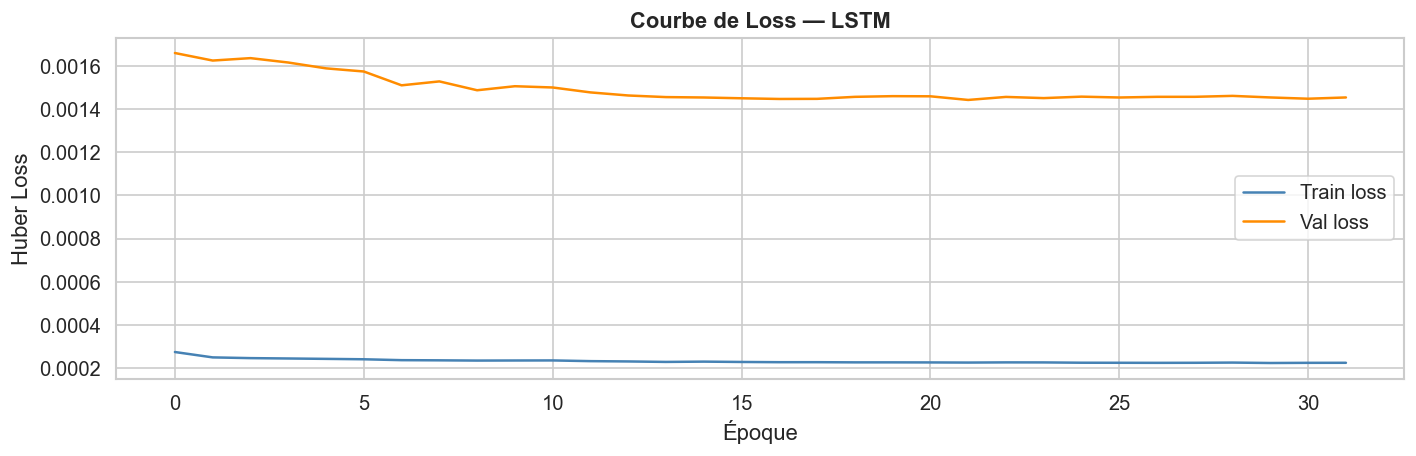

In [19]:
# ── Courbe de loss ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val loss',   color='darkorange')
ax.set_title('Courbe de Loss — LSTM', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('Huber Loss')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig26_lstm_loss.png', bbox_inches='tight')
plt.show()


📊 LSTM
   MAE  : 185.31 L
   RMSE : 506.73 L
   MAPE : 133.42 %


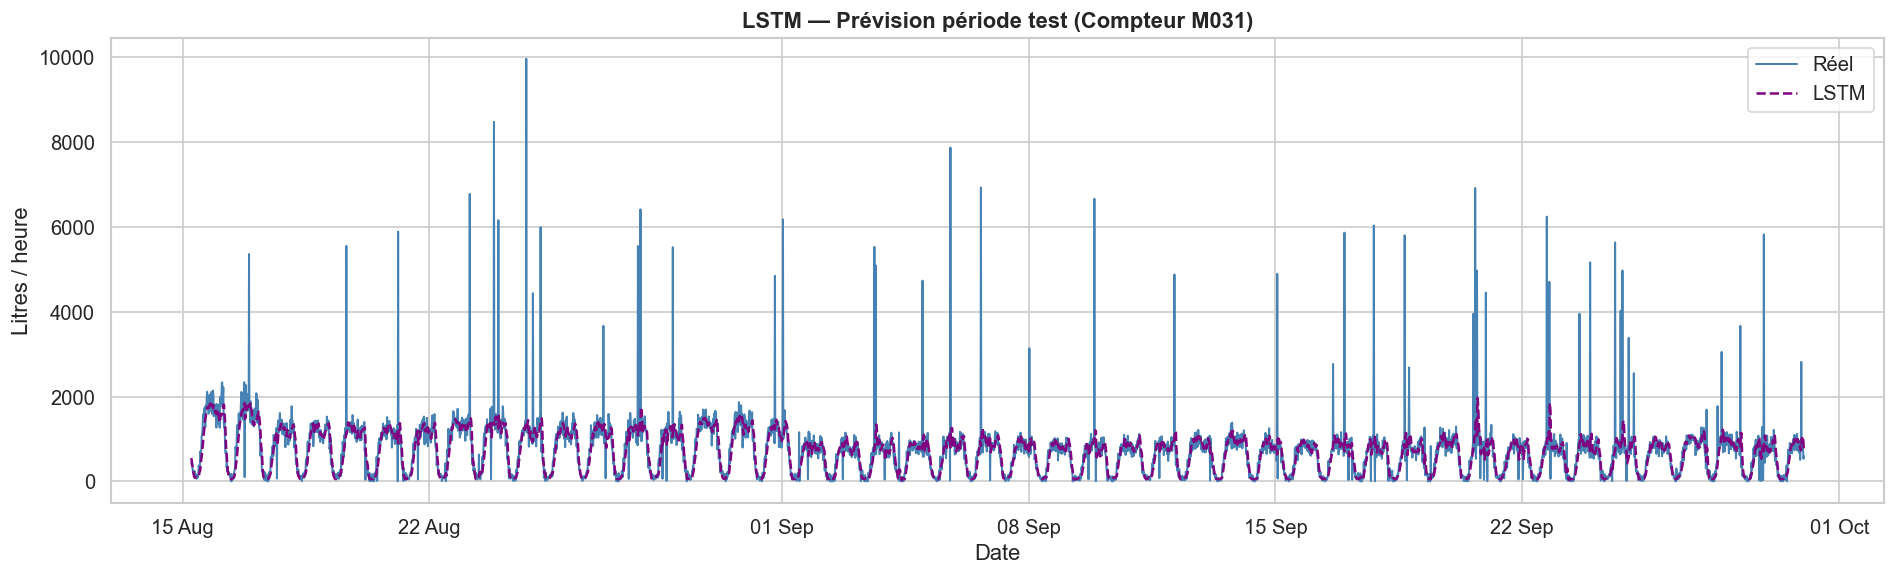

In [20]:
# ── Prédiction LSTM ───────────────────────────────────────────────────────────
pred_lstm_sc = model_lstm.predict(X_test_lstm, verbose=0)
pred_lstm = scaler_lstm.inverse_transform(pred_lstm_sc).flatten()
pred_lstm = np.clip(pred_lstm, 0, None)

y_test_lstm_inv = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

metrics_lstm = compute_metrics(y_test_lstm_inv, pred_lstm, 'LSTM')
results.append(metrics_lstm)

# ── Visualisation ─────────────────────────────────────────────────────────────
dates_test_m = test_m['timestamp'].values[SEQ_LEN:] if len(test_m) > SEQ_LEN else test_m['timestamp'].values
# Aligner les longueurs
n = min(len(dates_test_m), len(pred_lstm), len(y_test_lstm_inv))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_test_m[:n], y_test_lstm_inv[:n], label='Réel', color='steelblue', linewidth=1.2)
ax.plot(dates_test_m[:n], pred_lstm[:n], label='LSTM', color='purple', linewidth=1.5, linestyle='--')
ax.set_title(f'LSTM — Prévision période test (Compteur {TARGET_METER})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig27_lstm_prediction.png', bbox_inches='tight')
plt.show()

---
## 6. Comparaison des 4 Modèles

In [21]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).set_index('model')
df_results = df_results.sort_values('RMSE')

print('\n' + '='*55)
print('       COMPARAISON DES MODÈLES DE PRÉVISION')
print('='*55)
print(f'{"Modèle":<30} {"MAE":>8} {"RMSE":>8} {"MAPE":>8}')
print('-'*55)
for model, row in df_results.iterrows():
    print(f'{model:<30} {row["MAE"]:>7.1f}L {row["RMSE"]:>7.1f}L {row["MAPE"]:>7.1f}%')
print('='*55)
best_model = df_results.index[0]
print(f'\n🏆 Meilleur modèle : {best_model}')


       COMPARAISON DES MODÈLES DE PRÉVISION
Modèle                              MAE     RMSE     MAPE
-------------------------------------------------------
XGBoost                           48.6L   178.7L    11.3%
LSTM                             185.3L   506.7L   133.4%
Prophet                          440.9L   659.3L   255.7%
SARIMA(2,0,1)(1,0,1)[24]        1020.9L  1236.3L   170.3%

🏆 Meilleur modèle : XGBoost


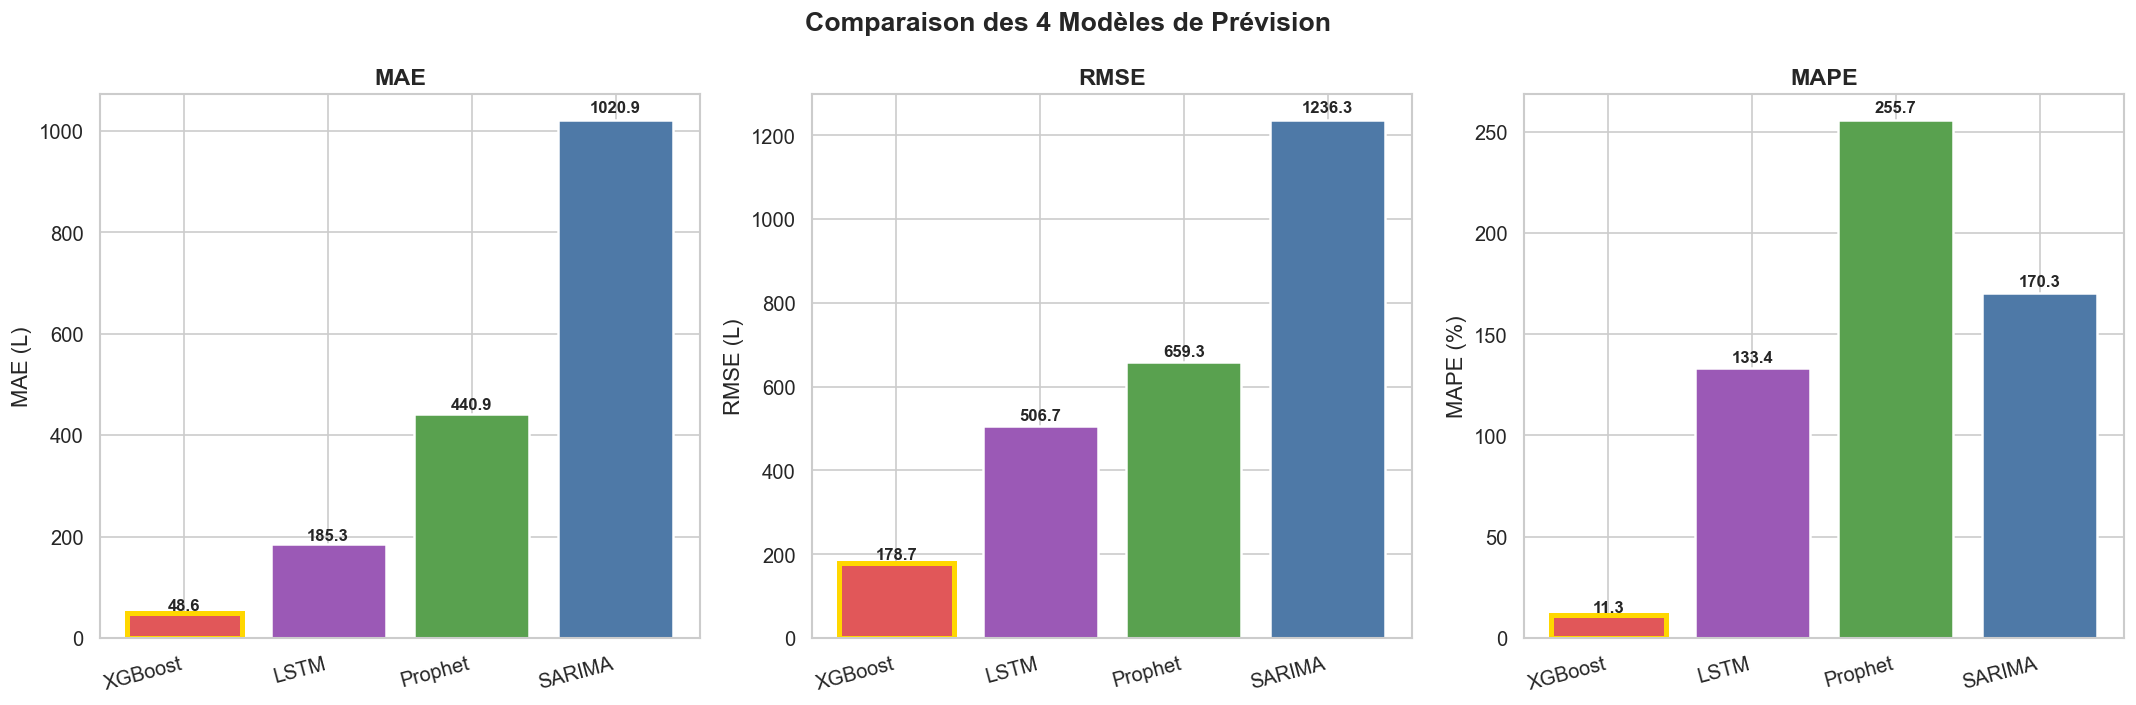

In [22]:
# ── Graphique comparatif des métriques ───────────────────────────────────────
model_colors = {
    'SARIMA(2,0,1)(1,0,1)[24]': '#4E79A7',
    'Prophet': '#59A14F',
    'XGBoost': '#E15759',
    'LSTM':    '#9B59B6'
}
colors_bar = [model_colors.get(m, '#888') for m in df_results.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    bars = ax.bar(range(len(df_results)), df_results[metric].values,
                  color=colors_bar, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(
        [m.split('(')[0] for m in df_results.index],
        rotation=15, ha='right'
    )
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    unit = ' (L)' if metric != 'MAPE' else ' (%)'
    ax.set_ylabel(metric + unit)
    # Annoter les valeurs
    for i, v in enumerate(df_results[metric].values):
        ax.text(i, v * 1.01, f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Mettre en évidence le meilleur
    best_idx = df_results[metric].values.argmin()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Comparaison des 4 Modèles de Prévision', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig28_comparaison_modeles.png', bbox_inches='tight')
plt.show()

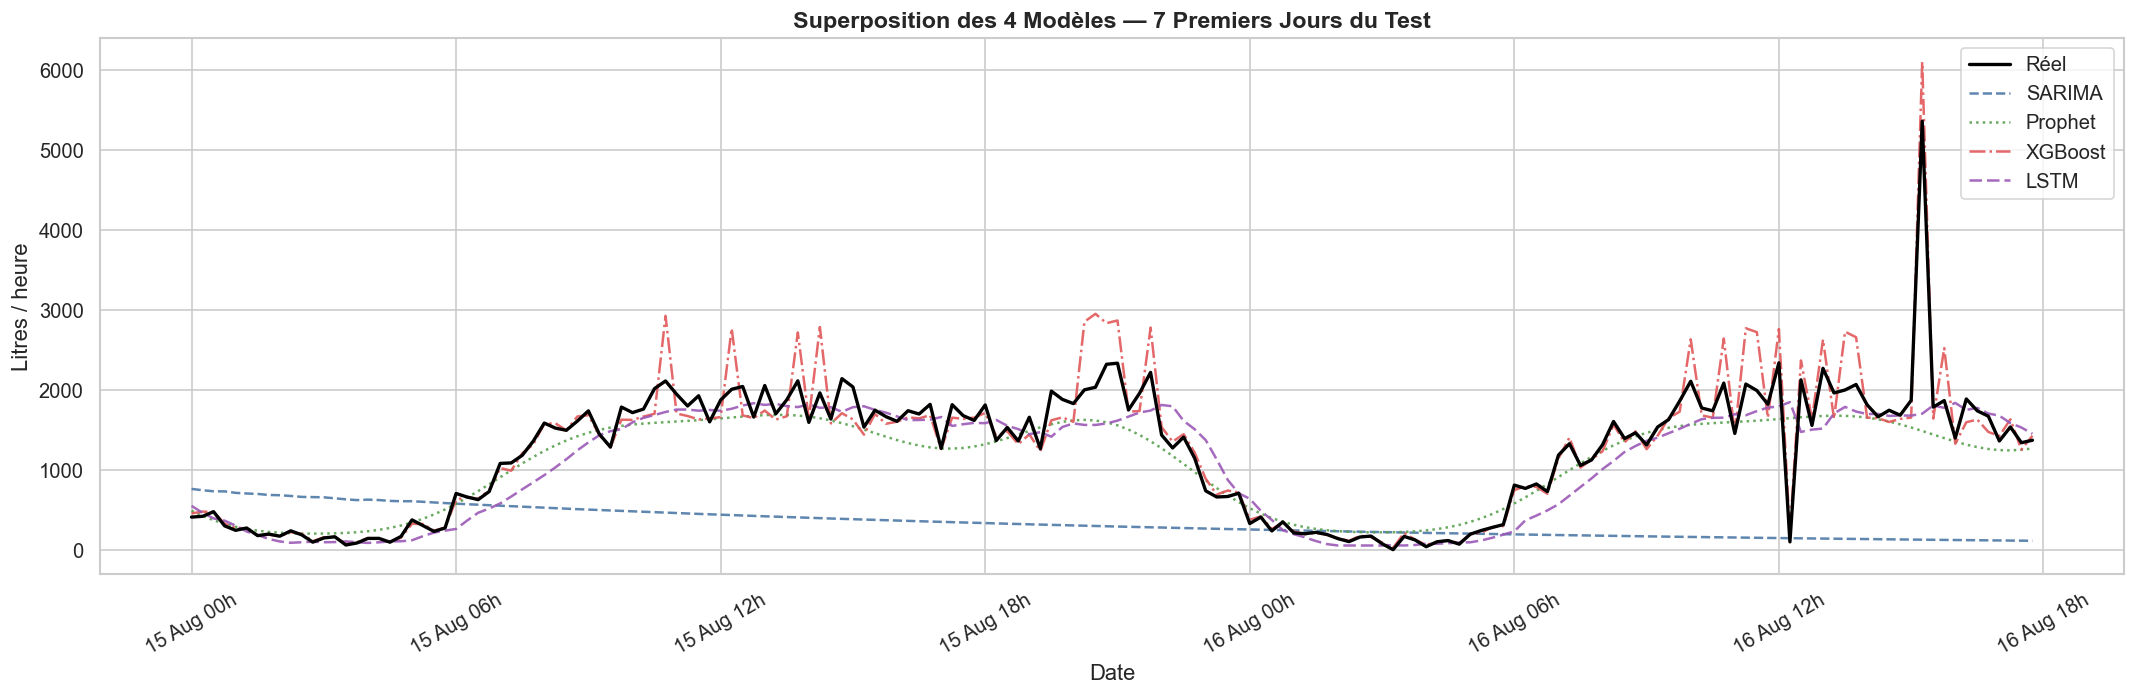

In [23]:
# ── Superposition des prédictions sur 7 jours ─────────────────────────────────
# Aligner toutes les prédictions sur la même fenêtre de 7 jours
N_PLOT = 24 * 7

# Réel (Prophet test, même compteur)
y_real_plot    = y_true_prophet[:N_PLOT]
dates_plot     = prophet_test['ds'].values[:N_PLOT]
pred_sarima_p  = pred_sarima[:N_PLOT] if len(pred_sarima) >= N_PLOT else np.pad(pred_sarima, (0, N_PLOT - len(pred_sarima)))
pred_prophet_p = pred_prophet[:N_PLOT]
pred_xgb_m_p   = pred_xgb_m[:N_PLOT] if len(pred_xgb_m) >= N_PLOT else np.pad(pred_xgb_m, (0, N_PLOT - len(pred_xgb_m)))
pred_lstm_p    = pred_lstm[:N_PLOT] if len(pred_lstm) >= N_PLOT else np.pad(pred_lstm, (0, N_PLOT - len(pred_lstm)))

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(dates_plot, y_real_plot, label='Réel', color='black', linewidth=2, zorder=5)
ax.plot(dates_plot, pred_sarima_p,  label='SARIMA',  color='#4E79A7', linewidth=1.5, linestyle='--', alpha=0.9)
ax.plot(dates_plot, pred_prophet_p, label='Prophet',  color='#59A14F', linewidth=1.5, linestyle=':',  alpha=0.9)
ax.plot(dates_plot, pred_xgb_m_p,   label='XGBoost',  color='#E15759', linewidth=1.5, linestyle='-.', alpha=0.9)
ax.plot(dates_plot, pred_lstm_p,    label='LSTM',     color='#9B59B6', linewidth=1.5, linestyle=(0,(5,2)), alpha=0.9)
ax.set_title('Superposition des 4 Modèles — 7 Premiers Jours du Test', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Hh'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig29_superposition_modeles.png', bbox_inches='tight')
plt.show()

---
## 7. Sauvegarde du Meilleur Modèle

In [24]:
# ── Sauvegarder tous les modèles + le meilleur ────────────────────────────────
print('💾 Sauvegarde des modèles...')

# XGBoost
joblib.dump(model_xgb, MODEL_DIR / 'xgboost_forecaster.pkl')
print('   ✅ xgboost_forecaster.pkl')

# Prophet
joblib.dump(model_prophet, MODEL_DIR / 'prophet_forecaster.pkl')
print('   ✅ prophet_forecaster.pkl')

# LSTM
model_lstm.save(MODEL_DIR / 'lstm_forecaster.h5')
joblib.dump(scaler_lstm, MODEL_DIR / 'lstm_scaler.pkl')
print('   ✅ lstm_forecaster.h5 + lstm_scaler.pkl')

# SARIMA (fitted values)
joblib.dump(fit_sarima, MODEL_DIR / 'sarima_forecaster.pkl')
print('   ✅ sarima_forecaster.pkl')

# Meilleur modèle → best_forecaster
if best_model == 'XGBoost':
    joblib.dump(model_xgb, MODEL_DIR / 'best_forecaster.pkl')
elif best_model == 'Prophet':
    joblib.dump(model_prophet, MODEL_DIR / 'best_forecaster.pkl')
elif best_model == 'LSTM':
    model_lstm.save(MODEL_DIR / 'best_forecaster.h5')
else:
    joblib.dump(fit_sarima, MODEL_DIR / 'best_forecaster.pkl')

# Sauvegarder les résultats
df_results.to_csv(MODEL_DIR / 'forecasting_results.csv')

# Sauvegarder les features XGBoost pour le backend
joblib.dump(available, MODEL_DIR / 'xgb_features.pkl')

print(f'\n🏆 Meilleur modèle sauvegardé : {best_model}')
print(f'   → models/best_forecaster.*')

💾 Sauvegarde des modèles...
   ✅ xgboost_forecaster.pkl


   ✅ prophet_forecaster.pkl
   ✅ lstm_forecaster.h5 + lstm_scaler.pkl
   ✅ sarima_forecaster.pkl

🏆 Meilleur modèle sauvegardé : XGBoost
   → models/best_forecaster.*


In [25]:
# ── Récapitulatif final ───────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — NOTEBOOK 02 PRÉVISION DE CONSOMMATION           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  4 MODÈLES ENTRAÎNÉS ET COMPARÉS                                    ║
║                                                                      ║
║  SARIMA(2,0,1)(1,0,1)[24]                                           ║
║  → Modèle statistique de référence                                  ║
║  → Paramètres issus de l'ACF/PACF (notebook 01)                    ║
║  → Limité aux 7 premiers jours (vitesse)                            ║
║                                                                      ║
║  Prophet                                                            ║
║  → Saisonnalité daily + weekly + regressor event_type              ║
║  → Intervalle de confiance disponible pour le backend              ║
║                                                                      ║
║  XGBoost                                                            ║
║  → 22 features (lags, cycliques, météo, événements)                ║
║  → Early stopping sur validation interne                           ║
║  → Feature importance disponible pour interprétabilité             ║
║                                                                      ║
║  LSTM                                                               ║
║  → 2 couches LSTM (64→32) + Dropout + Dense                        ║
║  → Fenêtre glissante de 24h                                         ║
║  → Loss Huber (robuste aux outliers)                                ║
║                                                                      ║
║  MODÈLES SAUVEGARDÉS → models/                                      ║
║  FIGURES SAUVEGARDÉES → reports/figures/ (fig21 à fig29)            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print('\n📊 Résultats finaux :')
print(df_results.round(2).to_string())
print(f'\n🏆 Meilleur modèle (RMSE) : {best_model}')
print('\n🏁 Notebook 02 terminé. Prochaine étape → 03_anomaly_detection.ipynb')


╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — NOTEBOOK 02 PRÉVISION DE CONSOMMATION           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  4 MODÈLES ENTRAÎNÉS ET COMPARÉS                                    ║
║                                                                      ║
║  SARIMA(2,0,1)(1,0,1)[24]                                           ║
║  → Modèle statistique de référence                                  ║
║  → Paramètres issus de l'ACF/PACF (notebook 01)                    ║
║  → Limité aux 7 premiers jours (vitesse)                            ║
║                                                                      ║
║  Prophet                                                            ║
║  → Saisonnalité daily + weekly + regressor event_type              ║
║  → Intervalle de confiance disponible pour le backend      